In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm
from matplotlib.ticker import ScalarFormatter

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [2]:
data1 = np.load("2d-gaussian-wavepacket.npz")

t1 = data1["times"]

error_gaussian = data1["rel_l2_err"]

eta1 = data1["eta"]

In [3]:
data2 = np.load("2d-instability_error.npz")

t2 = data2["times"]

error_instability = data2["rel_l2_err"]

eta2 = data2["eta"]

In [4]:
data3 = np.load("2d-cylinder_error.npz")

t3 = data3["times"]

err3 = data3["rel_l2_err"]

eta3 = data3["eta"]

C:\Users\16237\AppData\Local\Temp\ipykernel_38952\1654125573.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=fontsize)


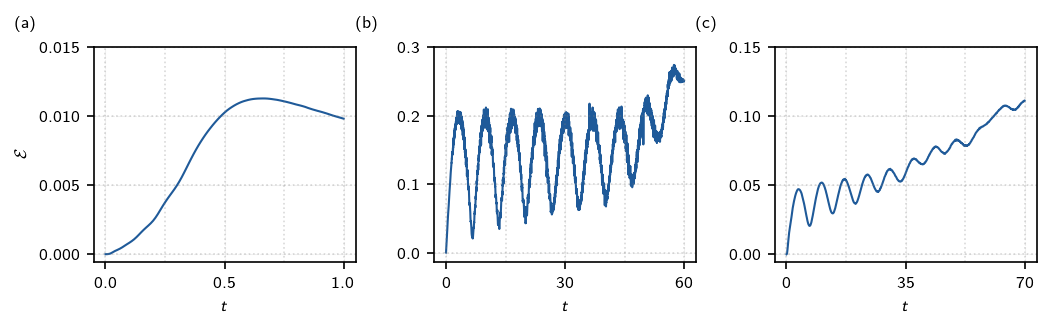

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


fontsize = 8
width = 17.9 / 2.54
height = width * 0.325


light_blue = '#AFCDEA'
mid_blue   = '#1f77b4'
dark_blue  = '#1F5A99'


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):

    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)

    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.3, y=1.15, fontsize=8):

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):

    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        ax.legend(frameon=False, fontsize=fontsize)

    add_panel_label(ax, panel_label)



panel_configs = [
    {
        "x": t1,
        "line_specs": [
            {"y": error_gaussian, "color": dark_blue, "linewidth": 1},

        ],
        "panel_label": "(a)",
        "xlabel": r"$t$",
        "ylabel": r"$\mathcal{E}$",
        "xticks": np.linspace(0, 1, 3),
        "yticks": np.linspace(0, 0.015, 4),
        "hline_values": np.linspace(0, 0.015, 4),
        "vline_values": np.linspace(0, 1, 5),
        "legend": True,
    },
    {
        "x": t2,
        "line_specs": [
            {
                "y": error_instability,
                "color": dark_blue,
                "linewidth": 1
            },
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 60, 3),
        "yticks": np.linspace(0, 0.3, 4),
        "hline_values": np.linspace(0, 0.3, 4),
        "vline_values": np.linspace(0, 60, 5),
        "legend": True,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
    {
        "x": t3,
        "line_specs": [
            {"y": err3, "color": dark_blue,  "linewidth": 1},
        ],
        "panel_label": "(c)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 70, 3),
        "yticks": np.linspace(0, 0.15, 4),
        "hline_values": np.linspace(0, 0.15, 4),
        "vline_values": np.linspace(0, 70, 5),
        "legend": True,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
]

def main():
    fig, axes = plt.subplots(1, 3, figsize=(width, height))

    for ax, cfg in zip(axes, panel_configs):
        setup_panel(
            ax=ax,
            x=cfg["x"],
            line_specs=cfg["line_specs"],
            panel_label=cfg["panel_label"],
            xlabel=cfg["xlabel"],
            ylabel=cfg["ylabel"],
            xticks=cfg["xticks"],
            yticks=cfg["yticks"],
            hline_values=cfg["hline_values"],
            vline_values=cfg["vline_values"],
            legend=cfg["legend"],
            y_sci=cfg.get("y_sci", False),
            sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
        )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    plt.savefig("2D_error.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
    plt.savefig("2D_error.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
    # plt.show()


if __name__ == "__main__":
    main()

C:\Users\16237\AppData\Local\Temp\ipykernel_38952\1241285567.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=fontsize)


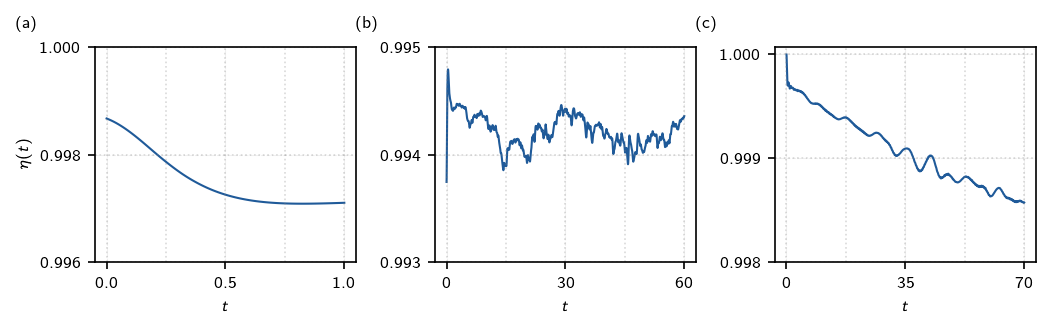

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


fontsize = 8
width = 17.9 / 2.54
height = width * 0.325


light_blue = '#AFCDEA'
mid_blue   = '#1f77b4'
dark_blue  = '#1F5A99'

def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):

    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)


    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.3, y=1.15, fontsize=8):

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):

    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        ax.legend(frameon=False, fontsize=fontsize)

    add_panel_label(ax, panel_label)



panel_configs = [
    {
        "x": t1,
        "line_specs": [
            {"y": eta1, "color": dark_blue, "linewidth": 1},

        ],
        "panel_label": "(a)",
        "xlabel": r"$t$",
        "ylabel": r"$\eta (t)$",
        "xticks": np.linspace(0, 1, 3),
        "yticks": np.linspace(0.996, 1, 3),
        "hline_values": np.linspace(0.996, 1, 3),
        "vline_values": np.linspace(0, 1, 5),
        "legend": True,
    },
    {
        "x": t2,
        "line_specs": [
            {
                "y": eta2,
                "color": dark_blue,
                "linewidth": 1
            },
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 60, 3),
        "yticks": np.linspace(0.993, 0.995, 3),
        "hline_values": np.linspace(0.993, 0.995, 3),
        "vline_values": np.linspace(0, 60, 5),
        "legend": True,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
    {
        "x": t3,
        "line_specs": [
            {"y": eta3, "color": dark_blue,  "linewidth": 1},
        ],
        "panel_label": "(c)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 70, 3),
        "yticks": np.linspace(0.998, 1, 3),
        "hline_values": np.linspace(0.998, 1, 3),
        "vline_values": np.linspace(0, 70, 5),
        "legend": True,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
]

def main():
    fig, axes = plt.subplots(1, 3, figsize=(width, height))

    for ax, cfg in zip(axes, panel_configs):
        setup_panel(
            ax=ax,
            x=cfg["x"],
            line_specs=cfg["line_specs"],
            panel_label=cfg["panel_label"],
            xlabel=cfg["xlabel"],
            ylabel=cfg["ylabel"],
            xticks=cfg["xticks"],
            yticks=cfg["yticks"],
            hline_values=cfg["hline_values"],
            vline_values=cfg["vline_values"],
            legend=cfg["legend"],
            y_sci=cfg.get("y_sci", False),
            sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
        )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    plt.savefig("2D_eta.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
    plt.savefig("2D_eta.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
    # plt.show()


if __name__ == "__main__":
    main()